In [ ]:
# =========================
# 1. IMPORT LIBRARY
# =========================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from imblearn.over_sampling import SMOTE

In [ ]:
# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv('Placement_Data_Full_Class (1).csv', sep=';')

print("DATA AWAL:")
print(df.head())

# =========================
# 3. DATA UNDERSTANDING
# =========================
print("\nINFO DATA:")
print(df.info())

print("\nSTATISTIK:")
print(df.describe())

DATA AWAL:
   sl_no gender  ssc_p    ssc_b  hsc_p    hsc_b     hsc_s  degree_p  \
0      1      M  67.00   Others  91.00   Others  Commerce     58.00   
1      2      M  79.33  Central  78.33   Others   Science     77.48   
2      3      M  65.00  Central  68.00  Central      Arts     64.00   
3      4      M  56.00  Central  52.00  Central   Science     52.00   
4      5      M  85.80  Central  73.60  Central  Commerce     73.30   

    degree_t workex  etest_p specialisation  mba_p      status  
0   Sci&Tech     No     55.0         Mkt&HR  58.80      Placed  
1   Sci&Tech    Yes     86.5        Mkt&Fin  66.28      Placed  
2  Comm&Mgmt     No     75.0        Mkt&Fin  57.80      Placed  
3   Sci&Tech     No     66.0         Mkt&HR  59.43  Not Placed  
4  Comm&Mgmt     No     96.8        Mkt&Fin  55.50      Placed  

INFO DATA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  -----

In [ ]:
# =========================
# 4. DATA PREPROCESSING
# =========================

# hapus kolom tidak penting
if 'sl_no' in df.columns:
    df = df.drop(columns=['sl_no'])

# hapus salary kalau masih ada
if 'salary' in df.columns:
    df = df.drop(columns=['salary'])

# missing value
df = df.dropna()

# encoding
le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

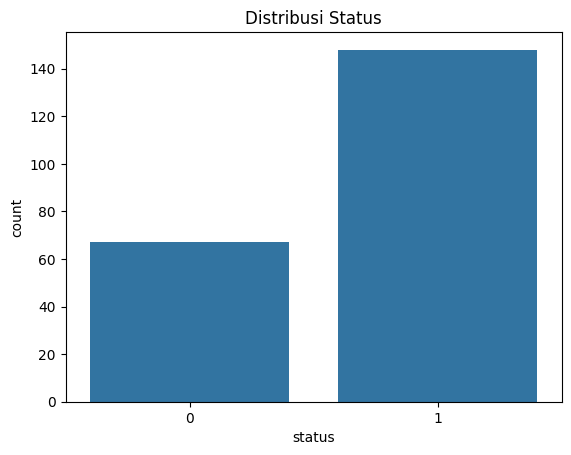

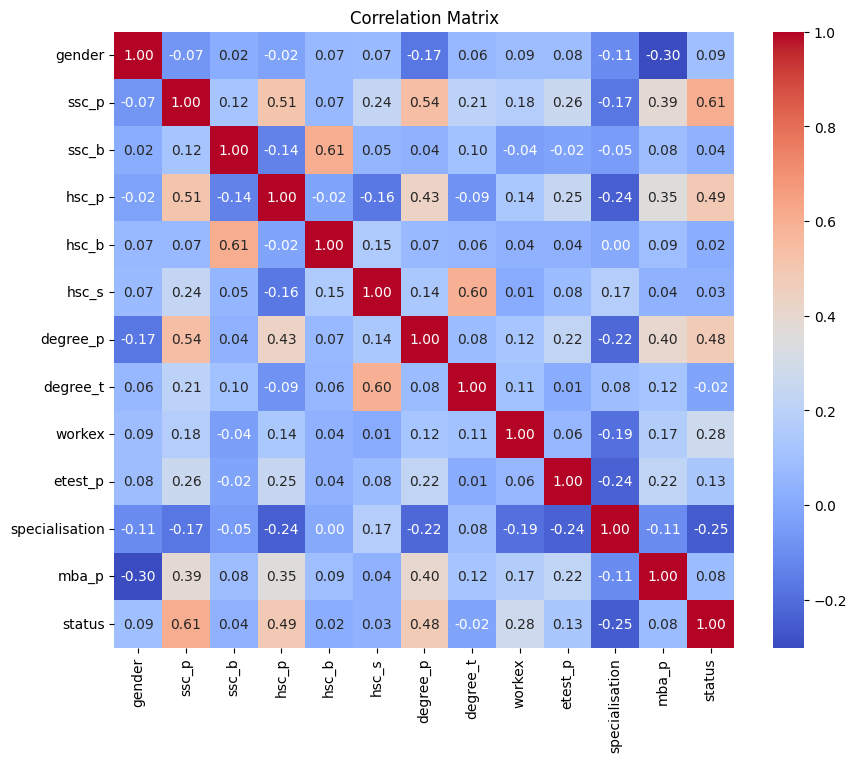

In [ ]:
# =========================
# 5. EDA
# =========================

# distribusi target
sns.countplot(x='status', data=df)
plt.title("Distribusi Status")
plt.show()

# korelasi
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# =========================
# 6. PREPARASI DATA
# =========================
X = df.drop('status', axis=1)
y = df['status']

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

# =========================
# 7. HANDLE IMBALANCE (SMOTE)
# =========================
smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

In [ ]:
# =========================
# 10. DATA SPLIT (3)
# =========================
splits = [
    (0.3, "70:30"),
    (0.2, "80:20"),
    (0.1, "90:10")
]

In [ ]:
# =========================
# 8. MODEL + PARAMETER (SUDAH DIPERBESAR 🔥)
# =========================
models = {
    "RandomForest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "ExtraTrees": ExtraTreesClassifier(class_weight='balanced', random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

In [ ]:
params = {
    "RandomForest": {
        "n_estimators": [150, 200],
        "max_depth": [10, 20],
        "min_samples_split": [2, 5]
    },
    "ExtraTrees": {
        "n_estimators": [150, 200],
        "max_depth": [10, 20]
    },
    "GradientBoosting": {
        "n_estimators": [150, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3]
    }
}


=== SPLIT 70:30 ===

Training RandomForest...
Accuracy: 0.9213483146067416
              precision    recall  f1-score   support

           0       0.90      0.96      0.92        45
           1       0.95      0.89      0.92        44

    accuracy                           0.92        89
   macro avg       0.92      0.92      0.92        89
weighted avg       0.92      0.92      0.92        89



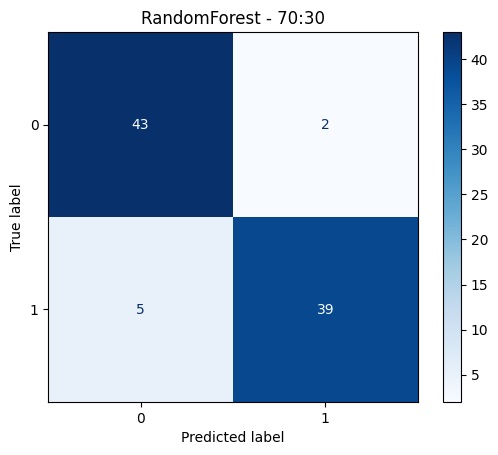


Training ExtraTrees...
Accuracy: 0.898876404494382
              precision    recall  f1-score   support

           0       0.85      0.98      0.91        45
           1       0.97      0.82      0.89        44

    accuracy                           0.90        89
   macro avg       0.91      0.90      0.90        89
weighted avg       0.91      0.90      0.90        89



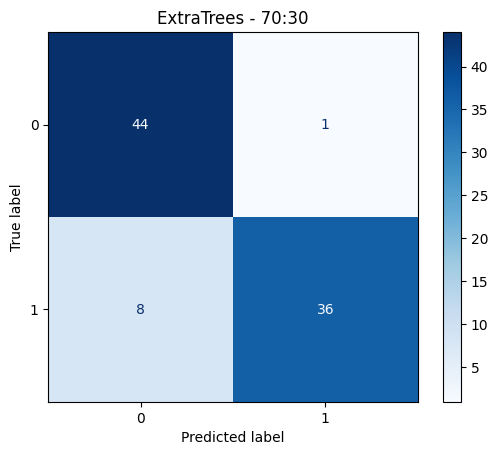


Training GradientBoosting...
Accuracy: 0.9101123595505618
              precision    recall  f1-score   support

           0       0.88      0.96      0.91        45
           1       0.95      0.86      0.90        44

    accuracy                           0.91        89
   macro avg       0.91      0.91      0.91        89
weighted avg       0.91      0.91      0.91        89



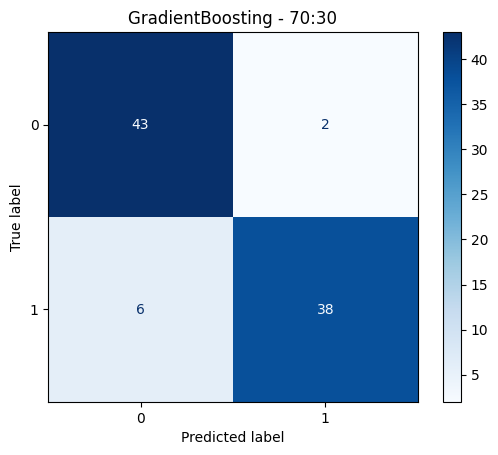


=== SPLIT 80:20 ===

Training RandomForest...
Accuracy: 0.8833333333333333
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        30
           1       0.93      0.83      0.88        30

    accuracy                           0.88        60
   macro avg       0.89      0.88      0.88        60
weighted avg       0.89      0.88      0.88        60



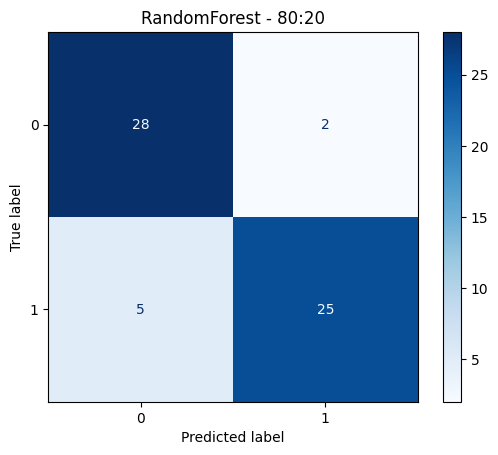


Training ExtraTrees...
Accuracy: 0.8666666666666667
              precision    recall  f1-score   support

           0       0.81      0.97      0.88        30
           1       0.96      0.77      0.85        30

    accuracy                           0.87        60
   macro avg       0.88      0.87      0.87        60
weighted avg       0.88      0.87      0.87        60



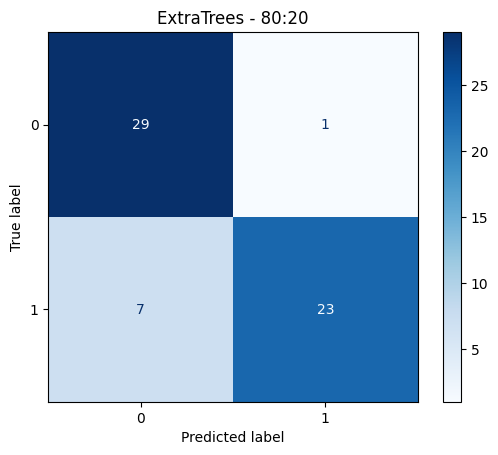


Training GradientBoosting...
Accuracy: 0.85
              precision    recall  f1-score   support

           0       0.78      0.97      0.87        30
           1       0.96      0.73      0.83        30

    accuracy                           0.85        60
   macro avg       0.87      0.85      0.85        60
weighted avg       0.87      0.85      0.85        60



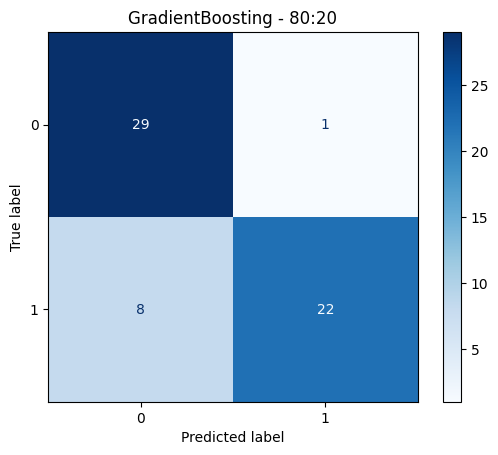


=== SPLIT 90:10 ===

Training RandomForest...
Accuracy: 0.8666666666666667
              precision    recall  f1-score   support

           0       0.82      0.93      0.88        15
           1       0.92      0.80      0.86        15

    accuracy                           0.87        30
   macro avg       0.87      0.87      0.87        30
weighted avg       0.87      0.87      0.87        30



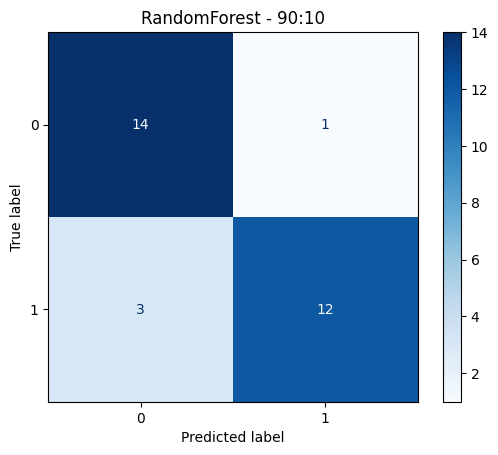


Training ExtraTrees...
Accuracy: 0.9
              precision    recall  f1-score   support

           0       0.88      0.93      0.90        15
           1       0.93      0.87      0.90        15

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



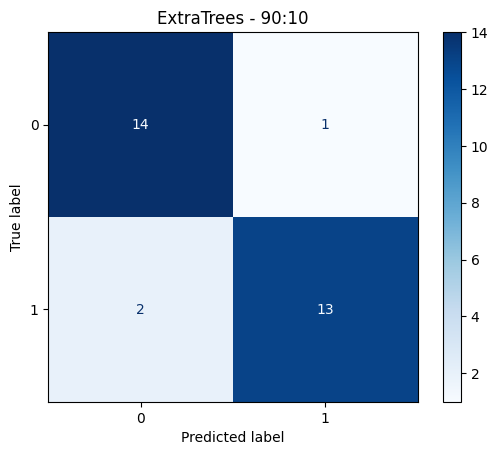


Training GradientBoosting...
Accuracy: 0.8666666666666667
              precision    recall  f1-score   support

           0       0.82      0.93      0.88        15
           1       0.92      0.80      0.86        15

    accuracy                           0.87        30
   macro avg       0.87      0.87      0.87        30
weighted avg       0.87      0.87      0.87        30



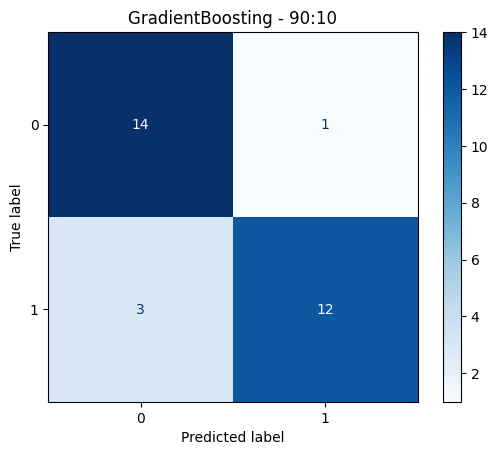

In [ ]:

# =========================
# 11. TRAINING + EVALUASI
# =========================
results = []

for test_size, name in splits:
    print(f"\n=== SPLIT {name} ===")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    for model_name in models:
        print(f"\nTraining {model_name}...")

        grid = GridSearchCV(
    models[model_name],
    params[model_name],
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
        grid.fit(X_train, y_train)

        y_pred = grid.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        results.append([name, model_name, acc])

        print(f"Accuracy: {acc}")
        print(classification_report(y_test, y_pred))

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(cm)
        disp.plot(cmap='Blues')
        plt.title(f"{model_name} - {name}")
        plt.show()

In [ ]:
# =========================
# 12. MODEL COMPARISON
# =========================
results_df = pd.DataFrame(results, columns=['Split', 'Model', 'Accuracy'])

print("\nHASIL SEMUA MODEL:")
print(results_df)


HASIL SEMUA MODEL:
   Split             Model  Accuracy
0  70:30      RandomForest  0.921348
1  70:30        ExtraTrees  0.898876
2  70:30  GradientBoosting  0.910112
3  80:20      RandomForest  0.883333
4  80:20        ExtraTrees  0.866667
5  80:20  GradientBoosting  0.850000
6  90:10      RandomForest  0.866667
7  90:10        ExtraTrees  0.900000
8  90:10  GradientBoosting  0.866667


In [14]:
import pickle
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier

# 1. Load dan Preprocess Data agar df tersedia
df = pd.read_csv('Placement_Data_Full_Class (1).csv', sep=';')
df = df.drop(columns=['sl_no'])
if 'salary' in df.columns: df = df.drop(columns=['salary'])
df = df.dropna()

# Label Encoding untuk kolom kategorikal
le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

# 2. Pisahkan Fitur dan Target
X = df.drop('status', axis=1)
y = df['status']

# 3. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Handle Imbalance dengan SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

# 5. Re-train model dengan parameter terbaik
final_models = {
    "RandomForest": RandomForestClassifier(n_estimators=150, max_depth=10, class_weight="balanced", random_state=42).fit(X_res, y_res),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=150, max_depth=10, class_weight="balanced", random_state=42).fit(X_res, y_res),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=3, random_state=42).fit(X_res, y_res)
}

# 6. Simpan model dan scaler menggunakan library pickle
with open('placement_models.pkl', 'wb') as f:
    pickle.dump(final_models, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Berhasil! File placement_models.pkl dan scaler.pkl telah siap untuk Streamlit.")

Berhasil! File placement_models.pkl dan scaler.pkl telah siap untuk Streamlit.


### Streamlit Deployment Code (`app.py`)

Copy the code below into a file named `app.py`. Make sure `placement_models.pkl` and `scaler.pkl` are in the same folder.

In [15]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle

# Load assets menggunakan pickle
@st.cache_resource
def load_assets():
    try:
        with open('placement_models.pkl', 'rb') as f:
            models = pickle.load(f)
        with open('scaler.pkl', 'rb') as f:
            scaler = pickle.load(f)
        return models, scaler
    except FileNotFoundError:
        st.error("File model .pkl tidak ditemukan. Silakan jalankan sel ekspor di notebook terlebih dahulu.")
        return None, None

models, scaler = load_assets()

if models and scaler:
    st.set_page_config(page_title="Placement Predictor", layout="centered")
    st.title("🎓 Student Placement Prediction")
    st.markdown("Input detail mahasiswa untuk prediksi status penempatan.")

    col1, col2 = st.columns(2)

    with col1:
        gender = st.selectbox("Gender", ["M", "F"])
        ssc_p = st.number_input("SSC Percentage", 0.0, 100.0, 67.0)
        ssc_b = st.selectbox("SSC Board", ["Central", "Others"])
        hsc_p = st.number_input("HSC Percentage", 0.0, 100.0, 66.0)
        hsc_b = st.selectbox("HSC Board", ["Central", "Others"])
        hsc_s = st.selectbox("HSC Subject", ["Commerce", "Science", "Arts"])

    with col2:
        degree_p = st.number_input("Degree Percentage", 0.0, 100.0, 66.0)
        degree_t = st.selectbox("Degree Type", ["Sci&Tech", "Comm&Mgmt", "Others"])
        workex = st.selectbox("Work Experience", ["Yes", "No"])
        etest_p = st.number_input("E-Test Percentage", 0.0, 100.0, 72.0)
        specialisation = st.selectbox("MBA Specialisation", ["Mkt&HR", "Mkt&Fin"])
        mba_p = st.number_input("MBA Percentage", 0.0, 100.0, 62.0)

    st.markdown("---")
    selected_algo = st.selectbox("🚀 Pilih Algoritma", list(models.keys()))

    if st.button("Prediksi Penempatan"):
        data = {
            "gender": 1 if gender == "M" else 0,
            "ssc_p": ssc_p,
            "ssc_b": 0 if ssc_b == "Central" else 1,
            "hsc_p": hsc_p,
            "hsc_b": 0 if hsc_b == "Central" else 1,
            "hsc_s": {"Arts": 0, "Commerce": 1, "Science": 2}[hsc_s],
            "degree_p": degree_p,
            "degree_t": {"Comm&Mgmt": 0, "Others": 1, "Sci&Tech": 2}[degree_t],
            "workex": 1 if workex == "Yes" else 0,
            "etest_p": etest_p,
            "specialisation": 0 if specialisation == "Mkt&Fin" else 1,
            "mba_p": mba_p
        }

        input_df = pd.DataFrame([data])
        input_scaled = scaler.transform(input_df)

        model = models[selected_algo]
        prediction = model.predict(input_scaled)
        prob = model.predict_proba(input_scaled)[0]

        if prediction[0] == 1:
            st.success(f"Hasil: **Placed** (Confidence: {prob[1]*100:.2f}%)")
            st.balloons()
        else:
            st.error(f"Hasil: **Not Placed** (Confidence: {prob[0]*100:.2f}%)")

Overwriting app.py
